In [6]:
import os
import cv2
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, cohen_kappa_score
from keras.models import Model
from keras import optimizers, applications
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input

# Set seeds to make the experiment more reproducible.
from tensorflow.random import set_seed
def seed_everything(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    set_seed(0)
seed_everything()

%matplotlib inline
sns.set(style="whitegrid")
warnings.filterwarnings("ignore")

In [7]:
train = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/train.csv')
test = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/test.csv')

In [8]:
print('Number of train samples: ', train.shape[0])
print('Number of test samples: ', test.shape[0])
display(train.head())

Number of train samples:  3662
Number of test samples:  1928


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


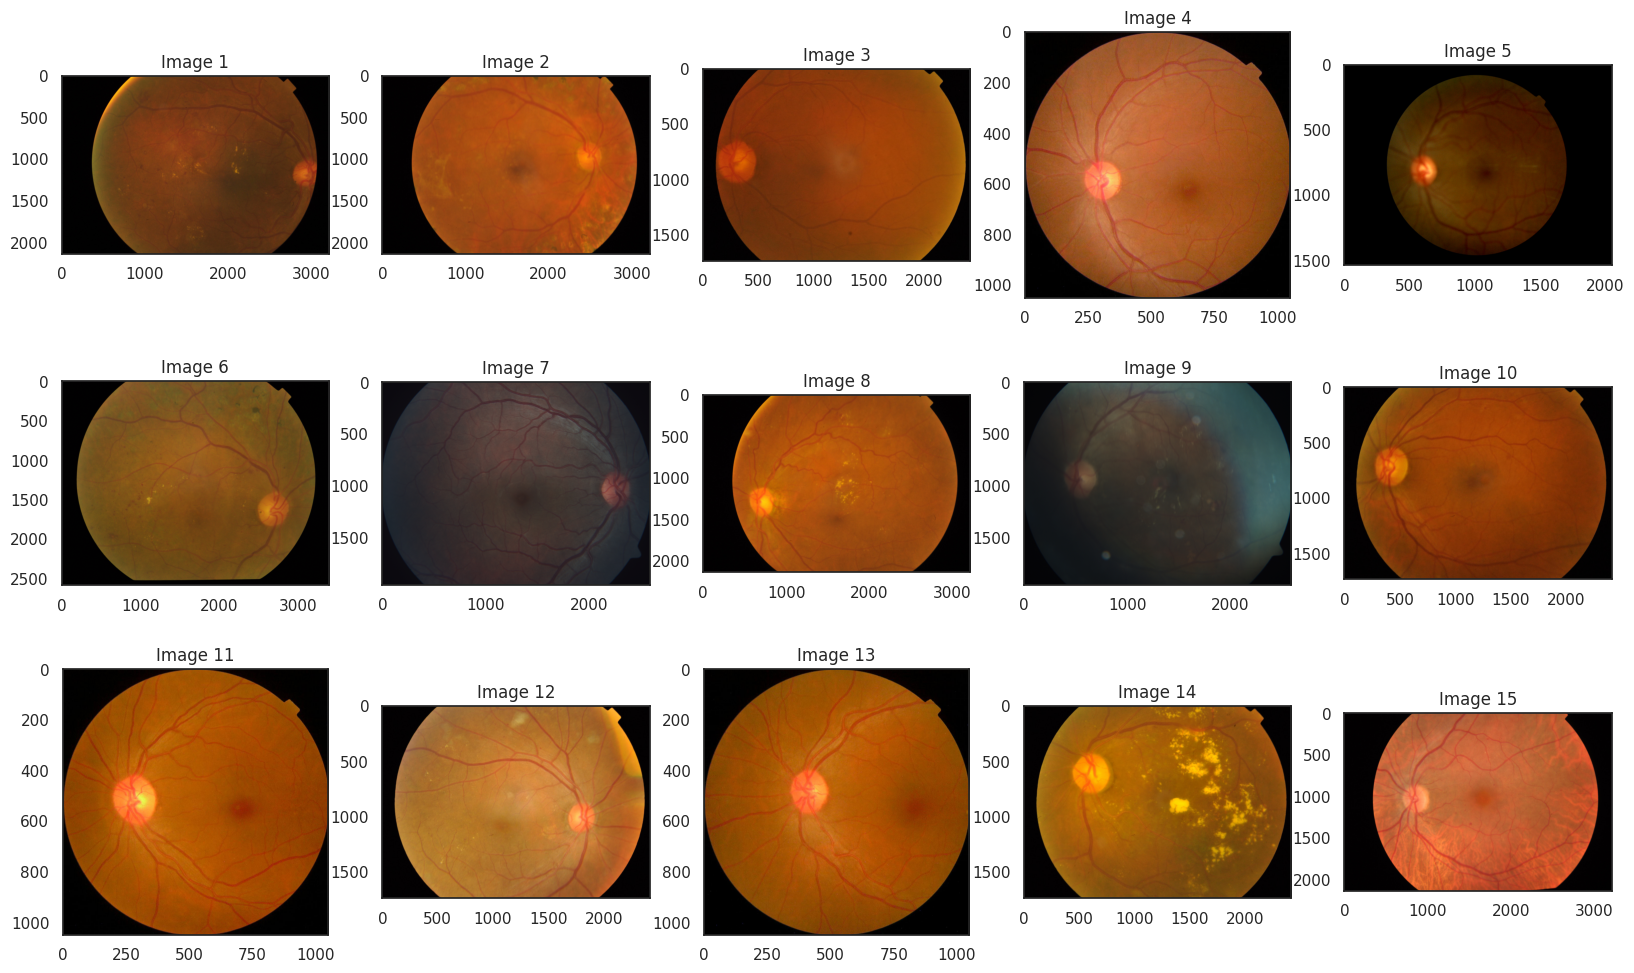

In [9]:
sns.set_style("white")
count = 1
plt.figure(figsize=[20, 20])
for img_name in train['id_code'][:15]:
    img = cv2.imread("/kaggle/input/aptos2019-blindness-detection/train_images/%s.png" % img_name)[...,[2, 1, 0]]
    plt.subplot(5, 5, count)
    plt.imshow(img)
    plt.title("Image %s" % count)
    count += 1
    
plt.show()

In [10]:
KAGGLE_DIR = '/kaggle/input/aptos2019-blindness-detection/'
TRAIN_DF_PATH = KAGGLE_DIR + "train.csv"
TEST_DF_PATH = KAGGLE_DIR + 'test.csv'
TRAIN_IMG_PATH = KAGGLE_DIR + "train_images/"
TEST_IMG_PATH = KAGGLE_DIR + 'test_images/'

In [11]:
# creating dataframes train and test
print("Image IDs and Labels (TRAIN)")
train_df = pd.read_csv(TRAIN_DF_PATH)
# Add extension to id_code
train_df['id_code'] = train_df['id_code'] + ".png"
print(f"Training images: {train_df.shape[0]}")
display(train_df.head())
print("Image IDs (TEST)")
test_df = pd.read_csv(TEST_DF_PATH)
# Add extension to id_code
test_df['id_code'] = test_df['id_code'] + ".png"
print(f"Testing Images: {test_df.shape[0]}")
display(test_df.head())

Image IDs and Labels (TRAIN)
Training images: 3662


,id_code,diagnosis
0,000c1434d8d7.png,2
1,001639a390f0.png,4
2,0024cdab0c1e.png,1
3,002c21358ce6.png,0
4,005b95c28852.png,0


Image IDs (TEST)
Testing Images: 1928


,id_code
0,0005cfc8afb6.png
1,003f0afdcd15.png
2,006efc72b638.png
3,00836aaacf06.png
4,009245722fa4.png


In [12]:
# Labels for training data
y_labels = train_df['diagnosis'].values
y_labels[:5]

array([2, 4, 1, 0, 0])

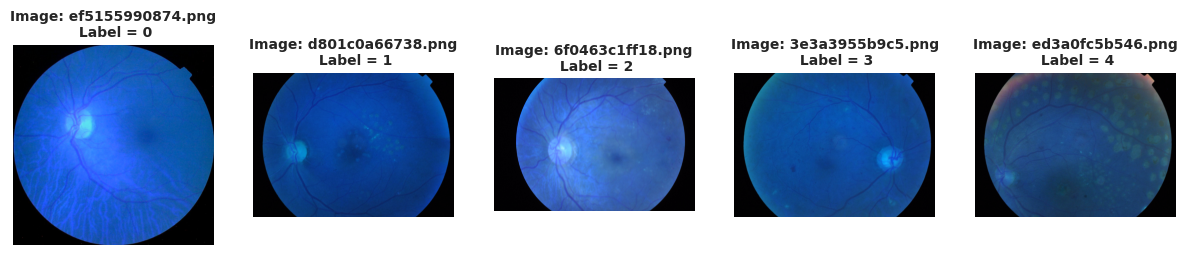

In [13]:
import cv2
SEED = 42
fig, ax = plt.subplots(1,5,figsize = (15,5))
for i in range(5):
    sample = train_df[train_df.diagnosis == i].sample(1,random_state=SEED)
    image_name = sample['id_code'].item()
    X = cv2.imread(f'{TRAIN_IMG_PATH}{image_name}')
    ax[i].set_title(f"Image: {image_name}\n Label = {sample['diagnosis'].item()}", weight='bold', fontsize=10)
    ax[i].axis('off')
    ax[i].imshow(X)

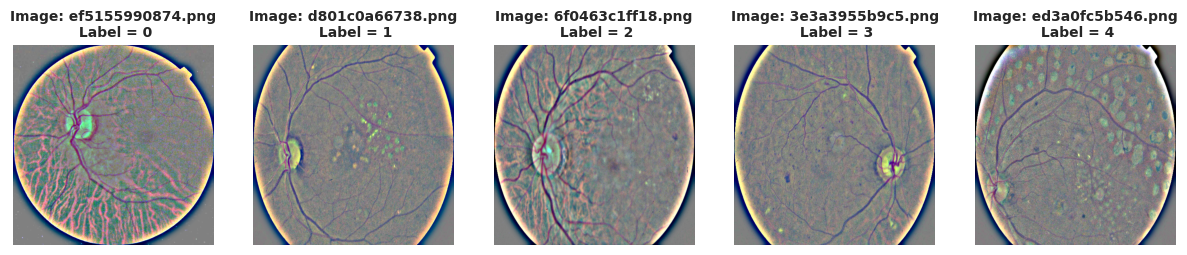

In [14]:
def crop_image_from_gray(img, tol=7):
    """
    Applies masks to the orignal image and 
    returns the a preprocessed image with 
    3 channels
    """
    # If for some reason we only have two channels
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1),mask.any(0))]
    # If we have a normal RGB images
    elif img.ndim == 3:
        gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray_img > tol
        
        check_shape = img[:,:,0][np.ix_(mask.any(1),mask.any(0))].shape[0]
        if (check_shape == 0): # image is too dark so that we crop out everything,
            return img # return original image
        else:
            img1=img[:,:,0][np.ix_(mask.any(1),mask.any(0))]
            img2=img[:,:,1][np.ix_(mask.any(1),mask.any(0))]
            img3=img[:,:,2][np.ix_(mask.any(1),mask.any(0))]
            img = np.stack([img1,img2,img3],axis=-1)
        return img

def preprocess_image(image, sigmaX=10):
    """
    The whole preprocessing pipeline:
    1. Read in image
    2. Apply masks
    3. Resize image to desired size
    4. Add Gaussian noise to increase Robustness
    """
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = crop_image_from_gray(image)
    image = cv2.resize(image, (512,512))
    image = cv2.addWeighted (image,4, cv2.GaussianBlur(image, (0,0) ,sigmaX), -4, 128)
    return image
# Specify image size
IMG_WIDTH = 224
IMG_HEIGHT = 224
CHANNELS = 3

import cv2

fig, ax = plt.subplots(1,5,figsize = (15,5))
for i in range(5):
    sample = train_df[train_df.diagnosis == i].sample(1,random_state=SEED)
    image_name = sample['id_code'].item()
    X = preprocess_image(cv2.imread(f'{TRAIN_IMG_PATH}{image_name}'))
    ax[i].set_title(f"Image: {image_name}\n Label = {sample['diagnosis'].item()}", weight='bold', fontsize=10)
    ax[i].axis('off')
    ax[i].imshow(X)

In [15]:
# Setting the model parameters
BATCH_SIZE =32
EPOCHS = 20
WARMUP_EPOCHS = 2
LEARNING_RATE = 1e-4
WARMUP_LEARNING_RATE = 1e-3
HEIGHT = 224
WIDTH = 224
CANAL = 3
N_CLASSES = train['diagnosis'].nunique()
ES_PATIENCE = 5
RLROP_PATIENCE = 3
DECAY_DROP = 0.5

In [16]:
from sklearn.model_selection import train_test_split
train_data, temp_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['diagnosis'])

# Split the temporary data into validation and test sets (50% validation, 50% test)
validation_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42, stratify=temp_data['diagnosis'])

# Convert the diagnosis column to string type
train_data['diagnosis'] = train_data['diagnosis'].astype(str)
validation_data['diagnosis'] = validation_data['diagnosis'].astype(str)
test_data['diagnosis'] = test_data['diagnosis'].astype(str)

# Check the number of samples in each set
print(f"Training samples: {len(train_data)}, Validation samples: {len(validation_data)}, Test samples: {len(test_data)}")

Training samples: 2929, Validation samples: 366, Test samples: 367


In [17]:
# Convert the diagnosis column to string type
train_data['diagnosis'] = train_data['diagnosis'].astype(str)
validation_data['diagnosis'] = validation_data['diagnosis'].astype(str)
test_data['diagnosis'] = test_data['diagnosis'].astype(str)

# ImageDataGenerator for training and validation
BATCH_SIZE = 32  # Adjust as needed
HEIGHT = 224     # Set your target height
WIDTH = 224      # Set your target width

train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True)

# Train generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    directory="/kaggle/input/aptos2019-blindness-detection/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    target_size=(HEIGHT, WIDTH)
)

# Validation generator
valid_generator = train_datagen.flow_from_dataframe(
    dataframe=validation_data,
    directory="/kaggle/input/aptos2019-blindness-detection/train_images/",
    x_col="id_code",
    y_col="diagnosis",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    target_size=(HEIGHT, WIDTH)
)

# Test generator
test_datagen = ImageDataGenerator(rescale=1./255)  # Assuming test images need rescaling only

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_data,
    directory="/kaggle/input/aptos2019-blindness-detection/train_images/",
    x_col="id_code",
    y_col="diagnosis",  # This will be unused in test generator but needs to be provided
    target_size=(HEIGHT, WIDTH),
    batch_size=1,
    shuffle=False,
    class_mode="categorical"  
)

Found 2929 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 367 validated image filenames belonging to 5 classes.


In [18]:
from tensorflow.keras import applications, optimizers
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def create_model(input_shape, n_out):
    input_tensor = Input(shape=input_shape)
    base_model = applications.DenseNet201(weights='imagenet', 
                                          include_top=False,
                                          input_tensor=input_tensor)

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    x = Dense(2048, activation='relu')(x)
    x = Dropout(0.5)(x)
    final_output = Dense(n_out, activation='softmax', name='final_output')(x)
    model = Model(input_tensor, final_output)
    
    return model

In [28]:
import os
from keras import applications, optimizers
from keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from keras.models import Model

def create_model(input_shape, n_out, base_model_weights_path=None):
    input_tensor = Input(shape=input_shape)
    
    # Create the DenseNet121 model without loading weights initially
    base_model = applications.DenseNet201(weights=None, include_top=False, input_tensor=input_tensor)
    
    # Load weights if a path is provided
    if base_model_weights_path:
        base_model.load_weights(base_model_weights_path)
    
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.5)(x)
    output = Dense(n_out, activation='softmax')(x)
    
    model = Model(inputs=input_tensor, outputs=output)
    return model

# Set your local path to the downloaded weights
local_weights_path = os.path.expanduser("/kaggle/input/densenet/keras/densenet201_imagenet/2/model.weights.h5")

# Define input shape and number of classes
input_shape = (224, 224, 3)  # Replace with HEIGHT, WIDTH, CANAL if variables are defined
n_out = N_CLASSES  # Replace N_CLASSES with the number of output classes

# Create the model and load weights if provided
model = create_model(input_shape=input_shape, n_out=n_out, base_model_weights_path=local_weights_path)

# Freeze all layers initially
for layer in model.layers:
    layer.trainable = False

# Unfreeze the last 5 layers
num_layers_to_unfreeze = 5  # Define the number of layers to unfreeze
for layer in model.layers[-num_layers_to_unfreeze:]:
    layer.trainable = True

# Configure optimizer and compile the model
WARMUP_LEARNING_RATE = 1e-4
optimizer = optimizers.Adam(learning_rate=WARMUP_LEARNING_RATE)
metric_list = ["accuracy"]
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=metric_list)

# Display the model summary
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_8    │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_8… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_9    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_9… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,331,589 (69.93 MB)

 Trainable params: 13,445 (52.52 KB)

 Non-trainable params: 18,318,144 (69.88 MB)

In [29]:
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Enable training on all layers for fine-tuning
for layer in model.layers:
    layer.trainable = True

# Define the patience and decay factor parameters if not already set
ES_PATIENCE = 13           # Stops training after 10 epochs of no improvement in val_loss
RLROP_PATIENCE = 5         # Reduces learning rate after 5 epochs of no improvement in val_loss
DECAY_DROP = 0.5           # Factor to reduce learning rate by
LEARNING_RATE = 1e-4       # Initial learning rate

rlrop = ReduceLROnPlateau(monitor='val_loss', mode='min', patience=RLROP_PATIENCE, factor=DECAY_DROP, min_lr=1e-6, verbose=1)
mc = ModelCheckpoint('/kaggle/working/best_model.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)

# Compile model for multiclass classification
optimizer = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

# Callback list
callback_list = [mc, rlrop]

# Summary of the model
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_8    │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_8… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_9    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_9… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,331,589 (69.93 MB)

 Trainable params: 18,102,533 (69.06 MB)

 Non-trainable params: 229,056 (894.75 KB)

In [30]:
STEP_SIZE_TRAIN = train_generator.n//train_generator.batch_size
STEP_SIZE_VALID = valid_generator.n//valid_generator.batch_size

try:
    
    history_finetuning = model.fit(
        train_generator,
        steps_per_epoch=STEP_SIZE_TRAIN,
        validation_data=valid_generator,
        validation_steps=STEP_SIZE_VALID,
        epochs=30,
        callbacks=callback_list,
        verbose=1
    ).history
except Exception as e:
    print("An error occurred during training:", e)

Epoch 1/30


I0000 00:00:1730877402.168395     100 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_50', 8 bytes spill stores, 48 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_51', 4 bytes spill stores, 28 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_19', 20 bytes spill stores, 20 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_20', 24 bytes spill stores, 44 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_38', 8 bytes spill stores, 48 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_22', 12 bytes spill stores, 68 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_23', 1

61/91 ━━━━━━━━━━━━━━━━━━━━ 1:33 3s/step - accuracy: 0.4825 - loss: 1.3042

I0000 00:00:1730877796.541198     100 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_60', 24 bytes spill stores, 44 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_fusion_869', 4 bytes spill stores, 28 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_27', 20 bytes spill stores, 20 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_28', 24 bytes spill stores, 44 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_29', 8 bytes spill stores, 48 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_30', 12 bytes spill stores, 68 bytes spill loads
ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusi

91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5417 - loss: 1.1924
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/best_model.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 845s 6s/step - accuracy: 0.5432 - loss: 1.1895 - val_accuracy: 0.5000 - val_loss: 1.2945 - learning_rate: 1.0000e-04
Epoch 2/30
 1/91 ━━━━━━━━━━━━━━━━━━━━ 32s 358ms/step - accuracy: 0.7500 - loss: 0.6596
Epoch 2: val_accuracy did not improve from 0.50000
91/91 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.7500 - loss: 0.6596 - val_accuracy: 0.4286 - val_loss: 1.3370 - learning_rate: 1.0000e-04
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7544 - loss: 0.6687
Epoch 3: val_accuracy improved from 0.50000 to 0.70739, saving model to /kaggle/working/best_model.keras
91/91 ━━━━━━━━━━━━━━━━━━━━ 330s 3s/step - accuracy: 0.7546 - loss: 0.6683 - val_accuracy: 0.7074 - val_loss: 0.7921 - learning_rate: 1.0000e-04
Epoch 4/30
 1/91 ━━━━━━━━━━━━━━━━━━━━ 26s 292ms/step - accuracy: 0.8

In [31]:
# Evaluate the model using the test generator
test_loss, test_accuracy = model.evaluate(test_generator, steps=len(test_generator), verbose=1)

# Print the results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

367/367 ━━━━━━━━━━━━━━━━━━━━ 44s 103ms/step - accuracy: 0.8112 - loss: 0.6987
Test Loss: 0.6125
Test Accuracy: 0.8229


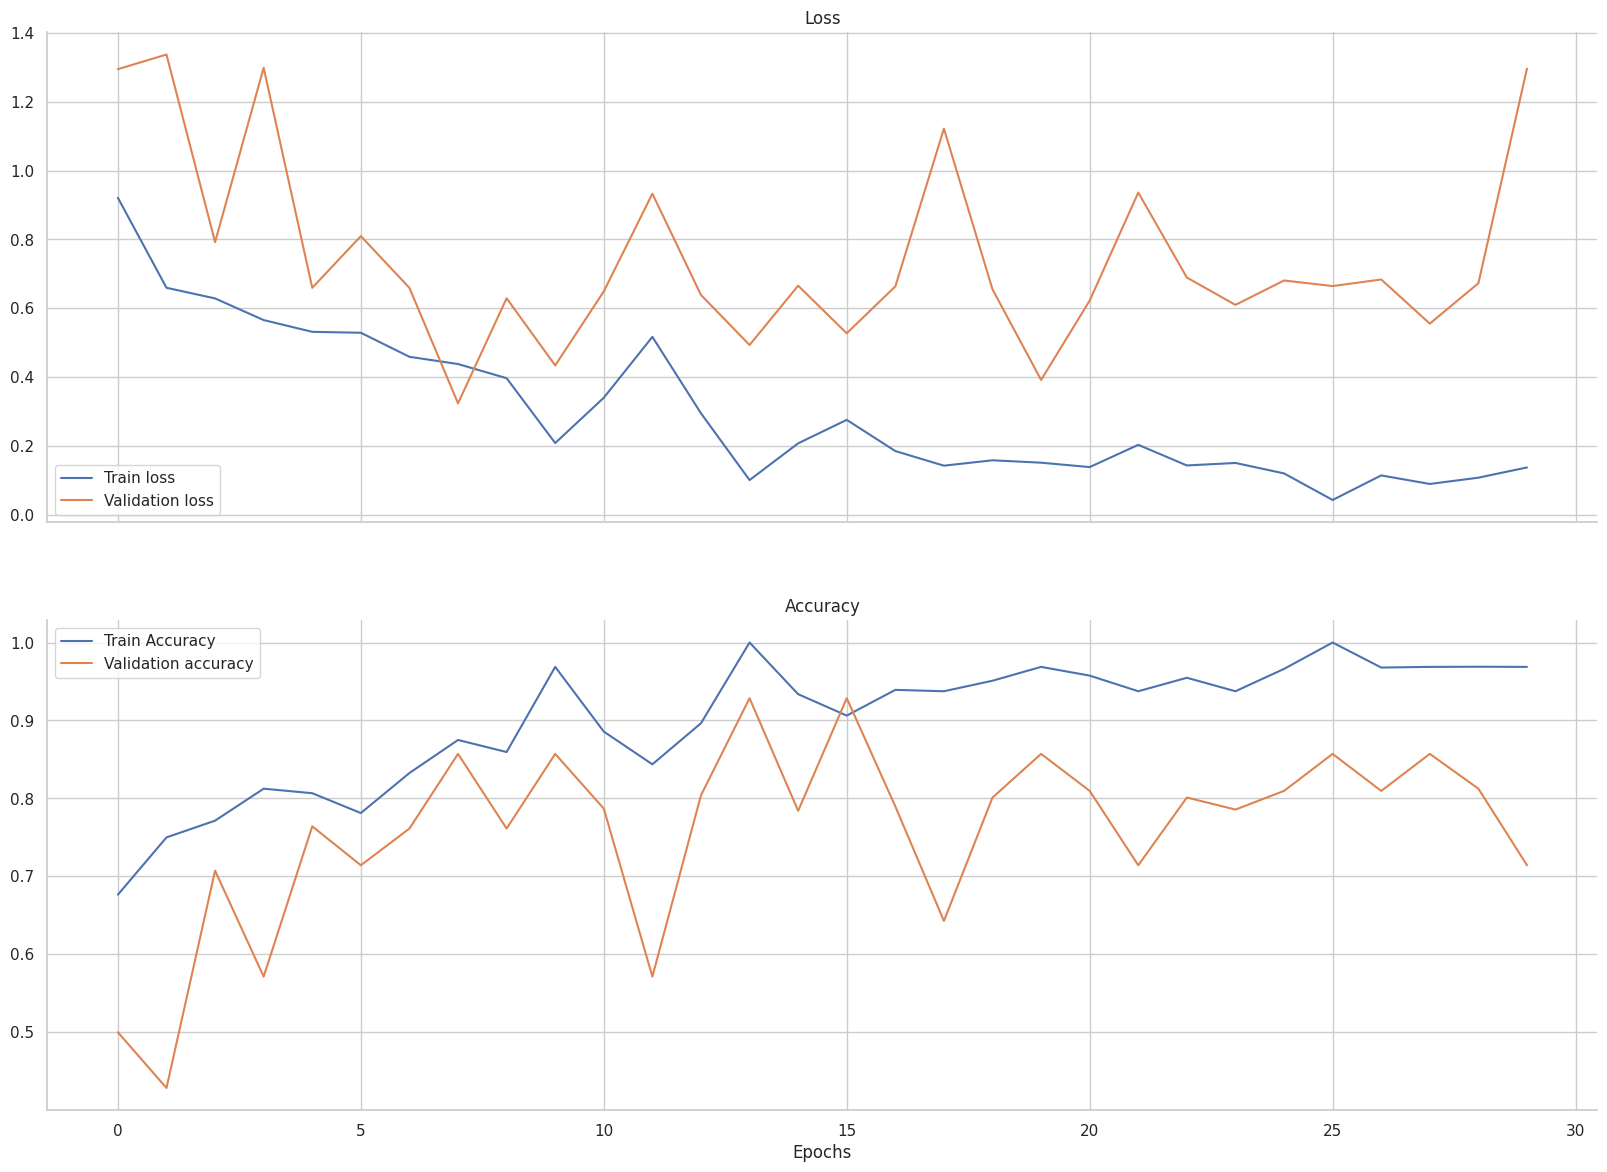

In [32]:
# Model loss graph
history = {
    'loss': history_finetuning['loss'],
    'val_loss':  history_finetuning['val_loss'],
    'accuracy': history_finetuning['accuracy'],
    'val_accuracy': history_finetuning['val_accuracy']
}

sns.set_style("whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, sharex='col', figsize=(20, 14))

ax1.plot(history['loss'], label='Train loss')
ax1.plot(history['val_loss'], label='Validation loss')
ax1.legend(loc='best')
ax1.set_title('Loss')

ax2.plot(history['accuracy'], label='Train Accuracy')
ax2.plot(history['val_accuracy'], label='Validation accuracy')
ax2.legend(loc='best')
ax2.set_title('Accuracy')

plt.xlabel('Epochs')
sns.despine()
plt.show()

367/367 ━━━━━━━━━━━━━━━━━━━━ 48s 101ms/step


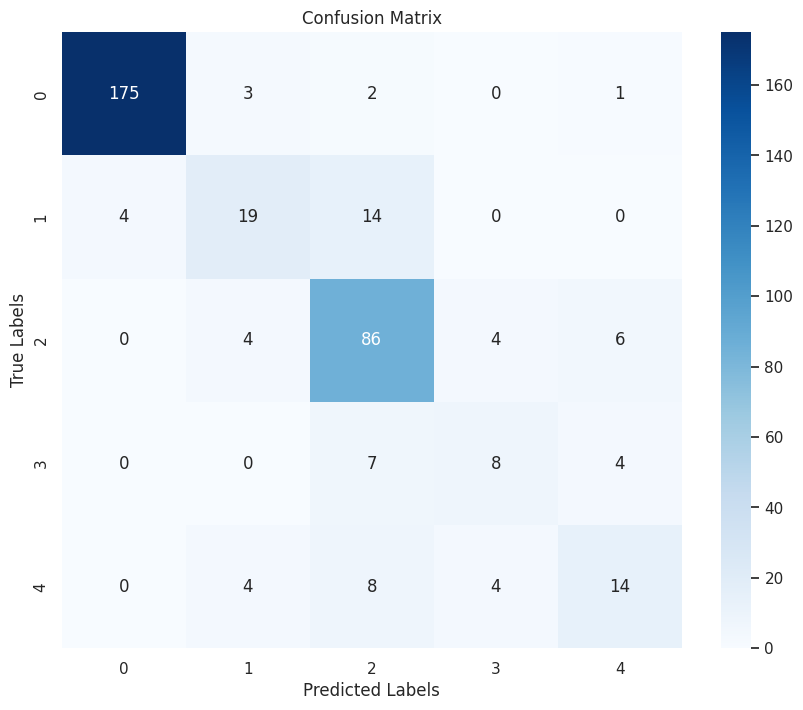

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       181
           1       0.63      0.51      0.57        37
           2       0.74      0.86      0.79       100
           3       0.50      0.42      0.46        19
           4       0.56      0.47      0.51        30

    accuracy                           0.82       367
   macro avg       0.68      0.65      0.66       367
weighted avg       0.82      0.82      0.82       367



In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get the true labels and predicted labels
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator, steps=len(test_generator), verbose=1), axis=1)

# Calculate confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_generator.class_indices.keys(), yticklabels=test_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))